In [6]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [159]:
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

from dotenv import load_dotenv

from langchain_core.globals import set_llm_cache, set_debug
from langchain_core.runnables import RunnableParallel
from langchain_core.output_parsers import StrOutputParser, JsonOutputParser
from langchain_community.cache import SQLiteCache

from langchain_openai import ChatOpenAI
from langchain_google_genai import ChatGoogleGenerativeAI

from lib import prompts
from lib.eval import (
    compute_metrics,
    evaluate_against_ground_truth,
    print_overview_metrics,
)
from lib.data_loader import GroundTruthsData, PatientsData, TrialsData

# .env contains OPENAI_API_KEY
load_dotenv()

set_debug(False)

# Set up LangChain caching
# Creates a local database file to store and reuse responses
cache = SQLiteCache(database_path=".langchain.db")
set_llm_cache(cache)

## testing llms

In [8]:
# LangChain automatically looks for 'OPENAI_API_KEY' if not explicitly passed.
llm_openai = ChatOpenAI(
    model="gpt-5-nano",  # TODO: change this to something else, but gpt-5-nano is the cheapest for prototyping now
    temperature=0,
)
response = llm_openai.invoke("hello")
print(response.content)

Hi there! Nice to meet you. What can I help you with today? I can explain concepts, draft text, brainstorm ideas, solve problems, or help you plan something. If you tell me your goal, I’ll tailor my assistance.


In [ ]:
response = (llm_openai | StrOutputParser()).invoke("hello")
print(response)

In [10]:
llm_google = ChatGoogleGenerativeAI(
    model="gemini-3.1-flash-lite-preview", temperature=0, max_retries=2
)

# w/o StrOutputParser, it returns as an array w/ a json object in it for text blocks etc
google_chain = llm_google | StrOutputParser()

response = google_chain.invoke("hello")
print(response)

Hello! How can I help you today?


In [11]:
formatted_msgs = prompts.PROMPT_TEMPLATE_ZERO_SHOT_COT.format_messages(
    patient_note="patient_note dummy text", clinical_trial="clinical_trial dummy text"
)

for m in formatted_msgs:
    m.pretty_print()

================================ System Message ================================

You are a medical expert with advanced knowledge in clinical reasoning, diagnostics, and treatment planning. Your task is to compare a given Patient Note and a Clinical Trial Description's Inclusion Criteria and Exclusion Criteria to determine the patient's eligibility at the criterion level.

The factors that allow someone to participate in a clinical study are called inclusion criteria. They are based on characteristics such as age, gender, the type and stage of a disease, previous treatment history, and other medical conditions.

The factors that disqualify someone from participating are called exclusion criteria. They are based on characteristics such as age, gender, the type and stage of a disease, previous treatment history, and other medical conditions.

Assess the given patient's eligibility for a clinical trial by evaluating each and every criterion individually.

### INCLUSION CRITERIA ASSESSMEN

# loading data

In [7]:
gt_data = GroundTruthsData()
pt_data = PatientsData()
tr_data = TrialsData()

In [12]:
pt_df = pd.Series(pt_data._lookup).to_frame(name="text")

pt_df["word_count"] = pt_df["text"].str.split().str.len()

total_words = pt_df["word_count"].sum()
dataset_overview = pt_df["word_count"].describe()

print(f"Total Words in Dataset: {total_words}")
print(dataset_overview)

Total Words in Dataset: 4058
count     52.000000
mean      78.038462
std       31.806992
min       38.000000
25%       59.750000
50%       69.000000
75%       91.750000
max      204.000000
Name: word_count, dtype: float64


In [21]:
# pd.set_option("display.max_colwidth", None)

tr_df = pd.Series(tr_data._lookup).to_frame(name="trial_obj")

tr_df["word_count"] = tr_df.apply(
    lambda row: len(tr_data.get_formatted_trial(row.name).split()), axis=1
)
# tr_df["formatted"] = tr_df.apply(
#     lambda row: tr_data.get_formatted_trial(row.name), axis=1
# )

# display(tr_df)

total_words = tr_df["word_count"].sum()
dataset_overview = tr_df["word_count"].describe()

print(f"Total Words in Dataset: {total_words}")
print(dataset_overview)

Total Words in Dataset: 26324
count    103.000000
mean     255.572816
std      165.590719
min       40.000000
25%      138.000000
50%      220.000000
75%      350.000000
max      888.000000
Name: word_count, dtype: float64


In [26]:
gt_df = pd.DataFrame(
    gt_data.get_patient_trial_pairs(), columns=["patient_id", "trial_id"]
)

trial_counts = gt_df.groupby("patient_id")["trial_id"].count()
mean_val = trial_counts.mean()
std_val = trial_counts.std()

print(f"Mean: {mean_val:.2f}")
print(f"Std Dev: {std_val:.2f}")

Mean: 1.98
Std Dev: 0.14


In [27]:
df = pd.DataFrame(
    list(gt_data._lookup.keys()),
    columns=["patient_id", "trial_id", "criterion_type", "criterion_text"],
)

counts = df.groupby("patient_id").size()

mean_val = counts.mean()
std_val = counts.std()

print(f"Mean criteria per patient: {mean_val:.2f}")
print(f"Standard Deviation: {std_val:.2f}")

Mean criteria per patient: 19.15
Standard Deviation: 9.57


## testing one

In [13]:
itr = iter(gt_data.get_patient_trial_pairs())
patient_id, trial_id = next(itr)

patient_info = pt_data.get(patient_id)

formatted_msgs = prompts.PROMPT_TEMPLATE_ZERO_SHOT.format_messages(
    patient_note=patient_info, clinical_trial=tr_data.get_formatted_trial(trial_id)
)
for m in formatted_msgs:
    m.pretty_print()


================================ System Message ================================

You are a medical expert with advanced knowledge in clinical reasoning, diagnostics, and treatment planning. Your task is to compare a given Patient Note and a Clinical Trial Description's Inclusion Criteria and Exclusion Criteria to determine the patient's eligibility at the criterion level.

The factors that allow someone to participate in a clinical study are called inclusion criteria. They are based on characteristics such as age, gender, the type and stage of a disease, previous treatment history, and other medical conditions.

The factors that disqualify someone from participating are called exclusion criteria. They are based on characteristics such as age, gender, the type and stage of a disease, previous treatment history, and other medical conditions.

Assess the given patient's eligibility for a clinical trial by evaluating each and every criterion individually.

### INCLUSION CRITERIA ASSESSMEN

In [14]:
zero_shot_chain = (
    prompts.PROMPT_TEMPLATE_ZERO_SHOT
    | llm_google
    | RunnableParallel(
        {"full_reasoning": lambda x: "N/A", "structured_data": JsonOutputParser()}
    )
)
zero_shot_google_response = zero_shot_chain.invoke(
    {
        "patient_note": pt_data.get(patient_id),
        "clinical_trial": tr_data.get_formatted_trial(trial_id),
    }
)

display(zero_shot_google_response)

{'full_reasoning': 'N/A',
 'structured_data': {'inclusion_criteria_evaluation': [{'criterion': 'Clinical diagnosis of hypertension',
    'classification': 'Met',
    'justification': 'The patient note explicitly states the patient is known to have hypertension.'},
   {'criterion': 'Clinical diagnosis of one or more risk factors, such as diabetes, smoking habit, lipid metabolism abnormality, history of ischemic heart disease (IHD) or cerebrovascular disease, obesity (BMI>25), chronic heart failure (NYHA II-III), and electrocardiogram (ECG) abnormality (LVH)',
    'classification': 'Met',
    'justification': 'The patient note explicitly states the patient has obesity.'}],
  'exclusion_criteria_evaluation': [{'criterion': 'Patients who have already been administered ARB',
    'classification': 'Not Violated',
    'justification': 'The patient note states she currently takes no medications.'},
   {'criterion': 'Patients with IHD within 6 months after percutaneous coronary intervention(PCI

In [15]:
cot_chain = (
    prompts.PROMPT_TEMPLATE_ZERO_SHOT_COT
    | llm_google
    | RunnableParallel(
        {"full_reasoning": StrOutputParser(), "structured_data": JsonOutputParser()}
    )
)

cot_chain_response = cot_chain.invoke(
    {
        "patient_note": pt_data.get(patient_id),
        "clinical_trial": tr_data.get_formatted_trial(trial_id),
    }
)

print(cot_chain_response["full_reasoning"])
display(cot_chain_response["structured_data"])

### Step-by-Step Analysis

1.  **Inclusion Criteria Analysis:**
    *   *Clinical diagnosis of hypertension:* The patient note explicitly states she is "known to have hypertension." (Met)
    *   *Clinical diagnosis of one or more risk factors (diabetes, smoking, lipid metabolism abnormality, history of IHD/cerebrovascular disease, obesity (BMI>25), chronic heart failure (NYHA II-III), ECG abnormality (LVH)):* The patient note states she has "obesity." (Met)

2.  **Exclusion Criteria Analysis:**
    *   *Patients who have already been administered ARB:* The patient note states she "currently takes no medications." (Not Violated)
    *   *Patients with IHD within 6 months after PCI, and who are stable but are going to implement PCI or CABG:* No evidence of prior PCI or planned procedures. (Not Violated)
    *   *Severe/malignant/secondary hypertensive patients:* No evidence of these specific hypertensive states. (Not Violated)
    *   *Pregnant women and women of childbearing potential:

{'inclusion_criteria_evaluation': [{'criterion': 'Clinical diagnosis of hypertension',
   'classification': 'Met',
   'justification': 'The patient note explicitly states the patient is known to have hypertension.'},
  {'criterion': 'Clinical diagnosis of one or more risk factors, such as diabetes, smoking habit, lipid metabolism abnormality, history of ischemic heart disease (IHD) or cerebrovascular disease, obesity (BMI>25), chronic heart failure (NYHA II-III), and electrocardiogram (ECG) abnormality (LVH)',
   'classification': 'Met',
   'justification': 'The patient note explicitly identifies that the patient has obesity.'}],
 'exclusion_criteria_evaluation': [{'criterion': 'Patients who have already been administered ARB',
   'classification': 'Not Violated',
   'justification': 'The patient note states she currently takes no medications.'},
  {'criterion': 'Patients with IHD within 6 months after percutaneous coronary intervention(PCI), and who are stable but are going to impleme

In [29]:
output, _ = evaluate_against_ground_truth(
    gt_data,
    tr_data,
    patient_id,
    trial_id,
    zero_shot_google_response["structured_data"],
)
display(pd.DataFrame(output))

output, _ = evaluate_against_ground_truth(
    gt_data,
    tr_data,
    patient_id,
    trial_id,
    cot_chain_response["structured_data"],
)
display(pd.DataFrame(output))

,criterion,criterion_type,predicted,expert_eligibility,model_match
0,Clinical diagnosis of hypertension,inclusion,Met,Met,True
1,Clinical diagnosis of one or more risk factors...,inclusion,Met,Met,True
2,Patients who have already been administered ARB,exclusion,Not Violated,Not Violated,True
3,Patients with IHD within 6 months after percut...,exclusion,Not Violated,Irrelevant,False
4,Severe/malignant/secondary hypertensive patients,exclusion,Not Violated,Not Violated,True
5,Pregnant women and women of childbearing poten...,exclusion,Unclear,Unclear,True
6,"History of heart failure, unstable angina, myo...",exclusion,Not Violated,Not Violated,True
7,Arrhythmia needed to be treated or accompanied...,exclusion,Not Violated,Not Violated,True
8,Severe renal impairment (Serum creatinine >3.0...,exclusion,Unclear,Not Violated,False
9,"Severe hepatic impairment (Hepatic failure, Ci...",exclusion,Not Violated,Not Violated,True


,criterion,criterion_type,predicted,expert_eligibility,model_match
0,Clinical diagnosis of hypertension,inclusion,Met,Met,True
1,Clinical diagnosis of one or more risk factors...,inclusion,Met,Met,True
2,Patients who have already been administered ARB,exclusion,Not Violated,Not Violated,True
3,Patients with IHD within 6 months after percut...,exclusion,Not Violated,Irrelevant,False
4,Severe/malignant/secondary hypertensive patients,exclusion,Not Violated,Not Violated,True
5,Pregnant women and women of childbearing poten...,exclusion,Unclear,Unclear,True
6,"History of heart failure, unstable angina, myo...",exclusion,Not Violated,Not Violated,True
7,Arrhythmia needed to be treated or accompanied...,exclusion,Not Violated,Not Violated,True
8,Severe renal impairment (Serum creatinine >3.0...,exclusion,Unclear,Not Violated,False
9,"Severe hepatic impairment (Hepatic failure, Ci...",exclusion,Unclear,Not Violated,False


# Display results nicer

In [ ]:
RESULTS_DIR = Path("results")


def load_all_experiments(results_dir: Path = RESULTS_DIR) -> dict[str, list[dict]]:
    experiments = {}
    for path in sorted(results_dir.glob("*.jsonl")):
        name = path.stem
        with open(path) as f:
            rows = [json.loads(line) for line in f if line.strip()]
        experiments[name] = rows
        print(f"  loaded '{name}': {len(rows)} rows")
    return experiments


def get_trialgpt_rows(gt_data: GroundTruthsData) -> list[dict]:
    return [
        {
            "criterion_type": key[2],
            "expert_eligibility": entry["expert_eligibility"],
            "predicted": entry["trialgpt_prediction"],
        }
        for key, entry in gt_data.items()
    ]

In [ ]:
def plot_all_confusion_matrices(
    all_experiments: list[tuple[str, dict]],
    row_letters: str,
    # didn't end up using this
    mode: str = "both",  # "inclusion", "exclusion", or "both"
    totals: dict = {
        "inclusion": 356,
        "exclusion": 659,
    },  # hardcoded from trialgpt ones, can pass it in but this was easier
) -> plt.Figure:
    INCLUSION_LABEL_ORDER = ["Met", "Not Met", "Unclear", "Irrelevant"]
    EXCLUSION_LABEL_ORDER = ["Violated", "Not Violated", "Unclear", "Irrelevant"]

    if mode == "both":
        splits = ("inclusion", "exclusion")
    elif mode in ("inclusion", "exclusion"):
        splits = (mode,)
    else:
        raise ValueError(
            f"mode must be 'inclusion', 'exclusion', or 'both', got {mode!r}"
        )

    n_rows = len(splits)
    n_cols = len(all_experiments)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(3 * n_cols, 3 * n_rows),
        squeeze=False,
    )

    for row_idx, split in enumerate(splits):
        axes[row_idx, 0].annotate(
            row_letters[row_idx],
            xy=(-0.8, 0.5),
            xycoords="axes fraction",
            fontsize=14,
            fontweight="bold",
            va="center",
        )

        for col_idx, exp in enumerate(all_experiments):
            exp_name, exp_metrics = exp
            ax = axes[row_idx, col_idx]
            m = exp_metrics[split]
            cm = m["confusion_matrix"]

            labels = (
                INCLUSION_LABEL_ORDER if split == "inclusion" else EXCLUSION_LABEL_ORDER
            )

            n = len(labels)

            matrix = np.array([[cm[row][col] for col in labels] for row in labels])
            row_sums = matrix.sum(axis=1, keepdims=True)
            normed = np.where(row_sums > 0, matrix / row_sums, 0)

            ax.imshow(normed, cmap="Blues", vmin=0, vmax=1)

            for i in range(n):
                for j in range(n):
                    val = normed[i, j]
                    text_color = "white" if val > 0.6 else "black"
                    ax.text(
                        j,
                        i,
                        f"{val:.2f}",
                        ha="center",
                        va="center",
                        fontsize=8,
                        color=text_color,
                        fontweight="bold",
                    )

            ax.set_xticks(range(n))
            ax.set_yticks(range(n))

            if row_idx == n_rows - 1:
                ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=9)
                ax.set_xlabel("Predictions", fontsize=8)
            else:
                ax.set_xticklabels([])
                # ax.xaxis.set_visible(False)

            if col_idx == 0:
                ax.set_yticklabels(labels, fontsize=9)
                ax.set_ylabel("Ground-truth", fontsize=8)
            else:
                ax.set_yticklabels([])
                # ax.yaxis.set_visible(False)

            acc = m["accuracy"]
            f1 = m["macro_f1"]

            # TODO: hardcoded here
            if "TrialGPT" in exp_name:
                n_str = f"{m['n_samples']}"
            else:
                n_str = (
                    f"{m['n_samples']} ({m['n_samples'] / totals[split] * 100:.0f}%)"
                )

            # if row_idx == 0:
            #     ax.set_title(
            #         f"{exp_name}\nAcc: {acc:.3f}\nF1: {f1:.3f}\nn: {n_str}",
            #         fontsize=12,
            #         pad=4,
            #     )
            # else:
            #     ax.set_title(
            #         f"Acc: {acc:.3f}\nF1: {f1:.3f}\nn: {n_str}",
            #         fontsize=12,
            #         pad=4,
            #     )

            if row_idx == 0:
                ax.text(
                    0.5,
                    1.28,  # increase to move it up
                    exp_name,
                    transform=ax.transAxes,
                    fontsize=12,
                    # fontweight="bold",
                    ha="center",
                    va="bottom",
                )
            ax.set_title(
                f"Acc: {acc:.3f}\nF1: {f1:.3f}\nn: {n_str}",
                fontsize=10,
                pad=4,
            )

    # i'm not sure this rect is doing anything
    fig.tight_layout(h_pad=2.0, w_pad=0, rect=[0.12, 0, 1, 1])
    # fig.subplots_adjust(wspace=0.01)

    # print(fig.get_size_inches())

  loaded 'cot__ollama': 875 rows
  loaded 'cot__ollama__temp05__0': 875 rows
  loaded 'cot__ollama__temp05__1': 869 rows
  loaded 'cot__ollama__temp05__2': 855 rows
  loaded 'cot__ollama__temp05__self_consistency': 871 rows
  loaded 'reflection__ollama': 818 rows
  loaded 'reflection__openai': 967 rows
  loaded 'specialists__ollama': 805 rows
  loaded 'specialists__openai': 912 rows
  loaded 'zero_shot__ollama': 880 rows
  loaded 'zero_shot__openai': 795 rows
[18.  6.]


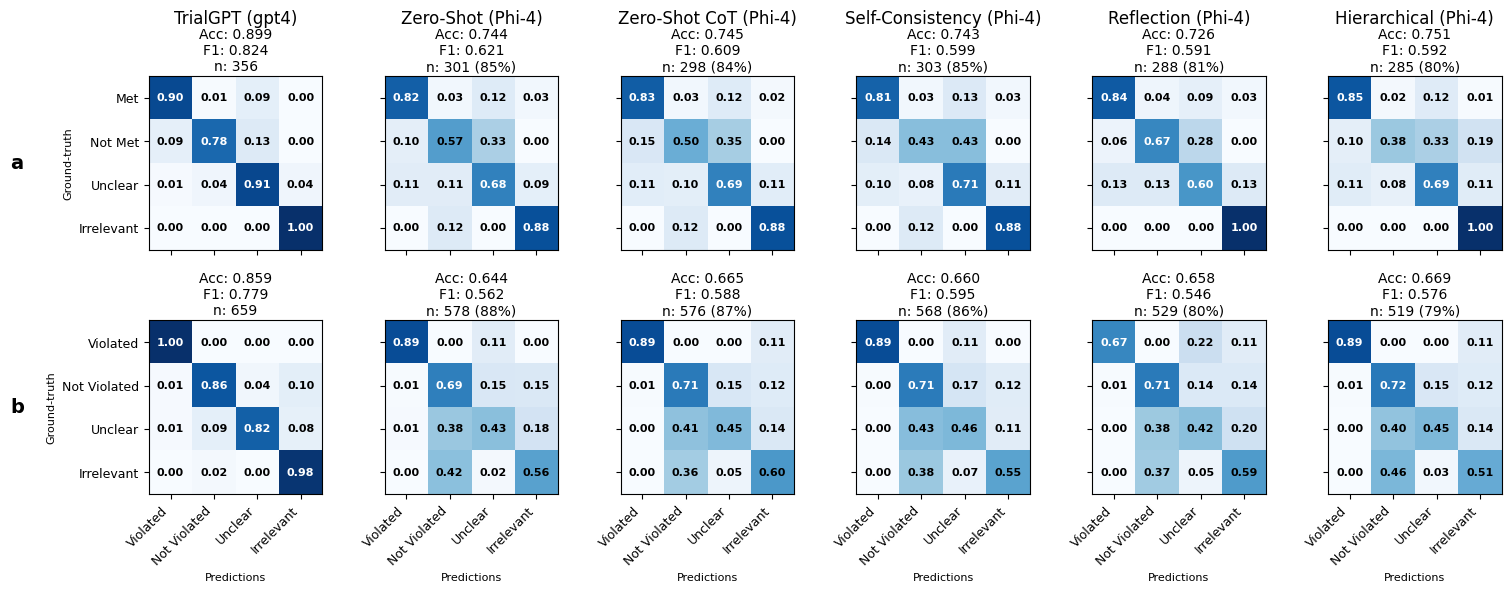

In [165]:
experiments = load_all_experiments()
trialgpt_metrics = compute_metrics(get_trialgpt_rows(gt_data))

desired_set_phi4 = [
    ("zero_shot__ollama", "Zero-Shot (Phi-4)"),
    ("cot__ollama", "Zero-Shot CoT (Phi-4)"),
    ("cot__ollama__temp05__self_consistency", "Self-Consistency (Phi-4)"),
    ("reflection__ollama", "Reflection (Phi-4)"),
    ("specialists__ollama", "Hierarchical (Phi-4)"),
]

subset_exp = [("TrialGPT (gpt4)", trialgpt_metrics)]
for name, display_name in desired_set_phi4:
    if name in experiments:
        subset_exp.append((display_name, compute_metrics(experiments[name])))

plot_all_confusion_matrices(subset_exp, row_letters="ab", mode="both")

  loaded 'cot__ollama': 875 rows
  loaded 'cot__ollama__temp05__0': 875 rows
  loaded 'cot__ollama__temp05__1': 869 rows
  loaded 'cot__ollama__temp05__2': 855 rows
  loaded 'cot__ollama__temp05__self_consistency': 871 rows
  loaded 'cot__openai': 964 rows
  loaded 'cot__openai__temp05__0': 961 rows
  loaded 'cot__openai__temp05__1': 949 rows
  loaded 'cot__openai__temp05__2': 938 rows
  loaded 'cot__openai__temp05__self_consistency': 965 rows
  loaded 'reflection__ollama': 818 rows
  loaded 'reflection__openai': 967 rows
  loaded 'specialists__ollama': 805 rows
  loaded 'specialists__openai': 912 rows
  loaded 'zero_shot__ollama': 880 rows
  loaded 'zero_shot__openai': 966 rows
[18.  6.]


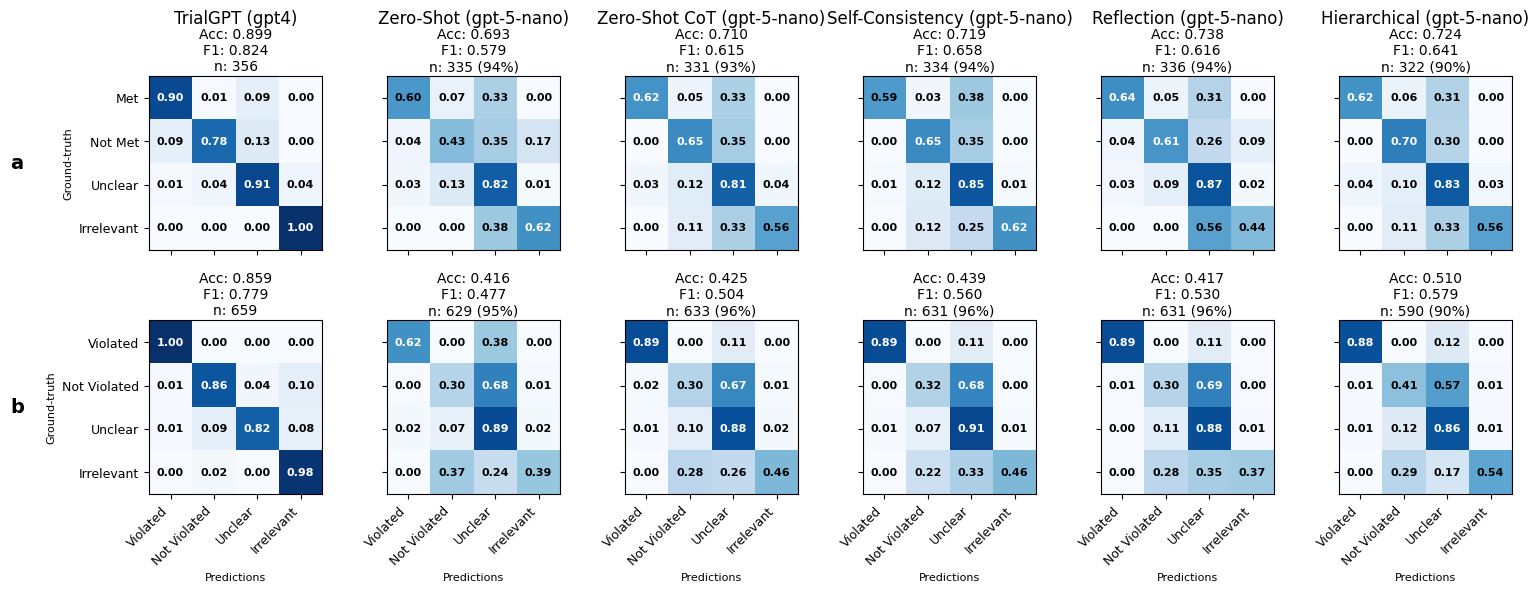

In [172]:
experiments = load_all_experiments()

trialgpt_metrics = compute_metrics(get_trialgpt_rows(gt_data))

desired_set_gpt = [
    ("zero_shot__openai", "Zero-Shot (gpt-5-nano)"),
    ("cot__openai", "Zero-Shot CoT (gpt-5-nano)"),
    ("cot__openai__temp05__self_consistency", "Self-Consistency (gpt-5-nano)"),
    ("reflection__openai", "Reflection (gpt-5-nano)"),
    ("specialists__openai", "Hierarchical (gpt-5-nano)"),
]

subset_exp = [("TrialGPT (gpt4)", trialgpt_metrics)]
for name, display_name in desired_set_gpt:
    if name in experiments:
        subset_exp.append((display_name, compute_metrics(experiments[name])))

# print(len(subset_exp))
# display(subset_exp)

plot_all_confusion_matrices(subset_exp, row_letters="ab", mode="both")

In [ ]:
experiments = load_all_experiments()

all_desired = desired_set_phi4[:] + desired_set_gpt[:]

# filter and remap to display_name
filtered = {}
for name, display_name in all_desired:
    if name in experiments:
        filtered[display_name] = experiments[name]

print(len(filtered))

print_overview_metrics(filtered, gt_data)

  loaded 'cot__ollama': 875 rows
  loaded 'cot__ollama__temp05__0': 875 rows
  loaded 'cot__ollama__temp05__1': 869 rows
  loaded 'cot__ollama__temp05__2': 855 rows
  loaded 'cot__ollama__temp05__self_consistency': 871 rows
  loaded 'cot__openai': 345 rows
  loaded 'reflection__ollama': 818 rows
  loaded 'reflection__openai': 967 rows
  loaded 'specialists__ollama': 805 rows
  loaded 'specialists__openai': 912 rows
  loaded 'zero_shot__ollama': 880 rows
  loaded 'zero_shot__openai': 966 rows
9

OVERVIEW — ALL EXPERIMENTS vs TrialGPT BASELINE
+-------------------+-----------------------+---------------------+-------------------------+----------------------------+
| Metric            |   TrialGPT (baseline) |   Zero-Shot (Phi-4) |   Zero-Shot CoT (Phi-4) |   Self-Consistency (Phi-4) |
+===================+=======================+=====================+=========================+============================+
| Accuracy          |                0.8729 |              0.6773 |                